# IDSC2026 — Brugada-HUCA Classification Baseline

## Objective
Membangun model klasifikasi biner untuk membedakan **Brugada syndrome** vs **Normal control**
menggunakan dataset **Brugada-HUCA**.

## Strategy
Pipeline yang digunakan:
1. Load metadata dan file ECG WFDB
2. Visualisasi dan quality check
3. Preprocessing sinyal
4. Deteksi R-peak dan ekstraksi median beat
5. Feature engineering full-strip + beat morphology
6. Train model XGBoost
7. Evaluasi AUC, F1, accuracy, sensitivity, specificity
8. Explainability dengan feature importance + SHAP

## Why this approach?
Karena jumlah data kecil, pendekatan tabular berbasis fitur morfologi ECG lebih:
- stabil
- explainable
- cocok untuk dataset kecil
- enak dipresentasikan saat video pitch

In [1]:
!pip -q install wfdb shap xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.3 MB/s eta 0:00:00


In [2]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from scipy.signal import butter, filtfilt, find_peaks, savgol_filter
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

from xgboost import XGBClassifier
import shap
import wfdb

RANDOM_STATE = 42
FS_EXPECTED = 100
STANDARD_LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

# 1. Locate dataset automatically
Notebook ini akan mencari `metadata.csv` dan semua file `.hea` secara rekursif di `/kaggle/input`.

In [3]:
INPUT_ROOT = "/kaggle/input"

meta_candidates = glob.glob(os.path.join(INPUT_ROOT, "**", "metadata.csv"), recursive=True)
assert len(meta_candidates) > 0, "metadata.csv tidak ditemukan di /kaggle/input"

META_PATH = meta_candidates[0]
DATASET_ROOT = os.path.dirname(META_PATH)

print("Metadata path:", META_PATH)
print("Dataset root :", DATASET_ROOT)

metadata = pd.read_csv(META_PATH)
display(metadata.head())

print("Shape metadata:", metadata.shape)
print("Columns:", metadata.columns.tolist())

Metadata path: /kaggle/input/datasets/izzarsulynashrudin/brugada-huca/metadata.csv
Dataset root : /kaggle/input/datasets/izzarsulynashrudin/brugada-huca


,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


Shape metadata: (363, 4)
Columns: ['patient_id', 'basal_pattern', 'sudden_death', 'brugada']


# 2. Basic EDA
Kita cek distribusi label target dan beberapa kolom penting.

brugada
0    287
1     69
2      7
Name: count, dtype: int64

brugada
0    0.790634
1    0.190083
2    0.019284
Name: proportion, dtype: float64


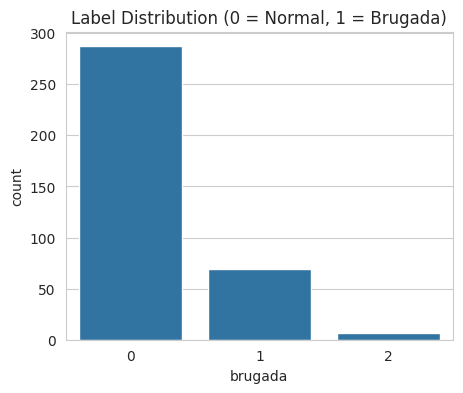

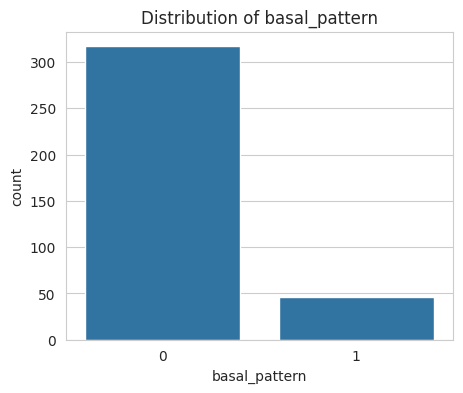

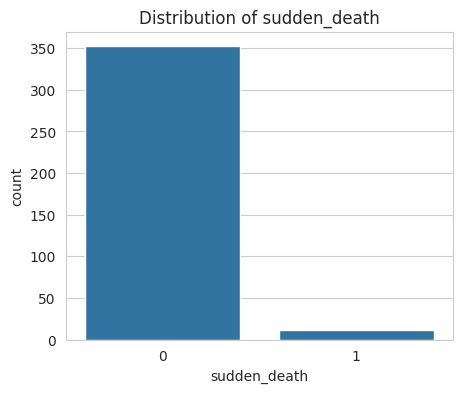

In [4]:
print(metadata["brugada"].value_counts(dropna=False))
print()
print(metadata["brugada"].value_counts(normalize=True).rename("proportion"))

plt.figure(figsize=(5,4))
sns.countplot(x=metadata["brugada"])
plt.title("Label Distribution (0 = Normal, 1 = Brugada)")
plt.show()

for col in ["basal_pattern", "sudden_death"]:
    if col in metadata.columns:
        plt.figure(figsize=(5,4))
        sns.countplot(x=metadata[col])
        plt.title(f"Distribution of {col}")
        plt.show()

In [5]:
hea_files = glob.glob(os.path.join(DATASET_ROOT, "**", "*.hea"), recursive=True)
print("Total .hea files found:", len(hea_files))

record_map = {}
for hea in hea_files:
    pid = os.path.splitext(os.path.basename(hea))[0]
    record_map[str(pid)] = os.path.splitext(hea)[0]

print("Indexed records:", len(record_map))

missing_ids = [str(pid) for pid in metadata["patient_id"].astype(str) if str(pid) not in record_map]
print("Missing patient IDs in file index:", len(missing_ids))
if len(missing_ids) > 0:
    print("Example missing IDs:", missing_ids[:10])

Total .hea files found: 363
Indexed records: 363
Missing patient IDs in file index: 0


In [6]:
def standardize_lead_names(sig_names):
    mapping = {}
    for s in sig_names:
        mapping[s] = s.strip().replace("AVR", "aVR").replace("AVL", "aVL").replace("AVF", "aVF")
    return mapping

def load_ecg_record(patient_id):
    patient_id = str(patient_id)
    assert patient_id in record_map, f"Record untuk patient_id {patient_id} tidak ditemukan"
    
    rec = wfdb.rdrecord(record_map[patient_id])
    sig = pd.DataFrame(rec.p_signal, columns=rec.sig_name)
    
    name_map = standardize_lead_names(sig.columns.tolist())
    sig = sig.rename(columns=name_map)
    
    # pastikan 12 lead urut
    for ld in STANDARD_LEADS:
        if ld not in sig.columns:
            raise ValueError(f"Lead {ld} tidak ditemukan pada patient_id {patient_id}")
    
    sig = sig[STANDARD_LEADS].copy()
    fs = rec.fs
    return sig.values.astype(np.float32), STANDARD_LEADS, fs

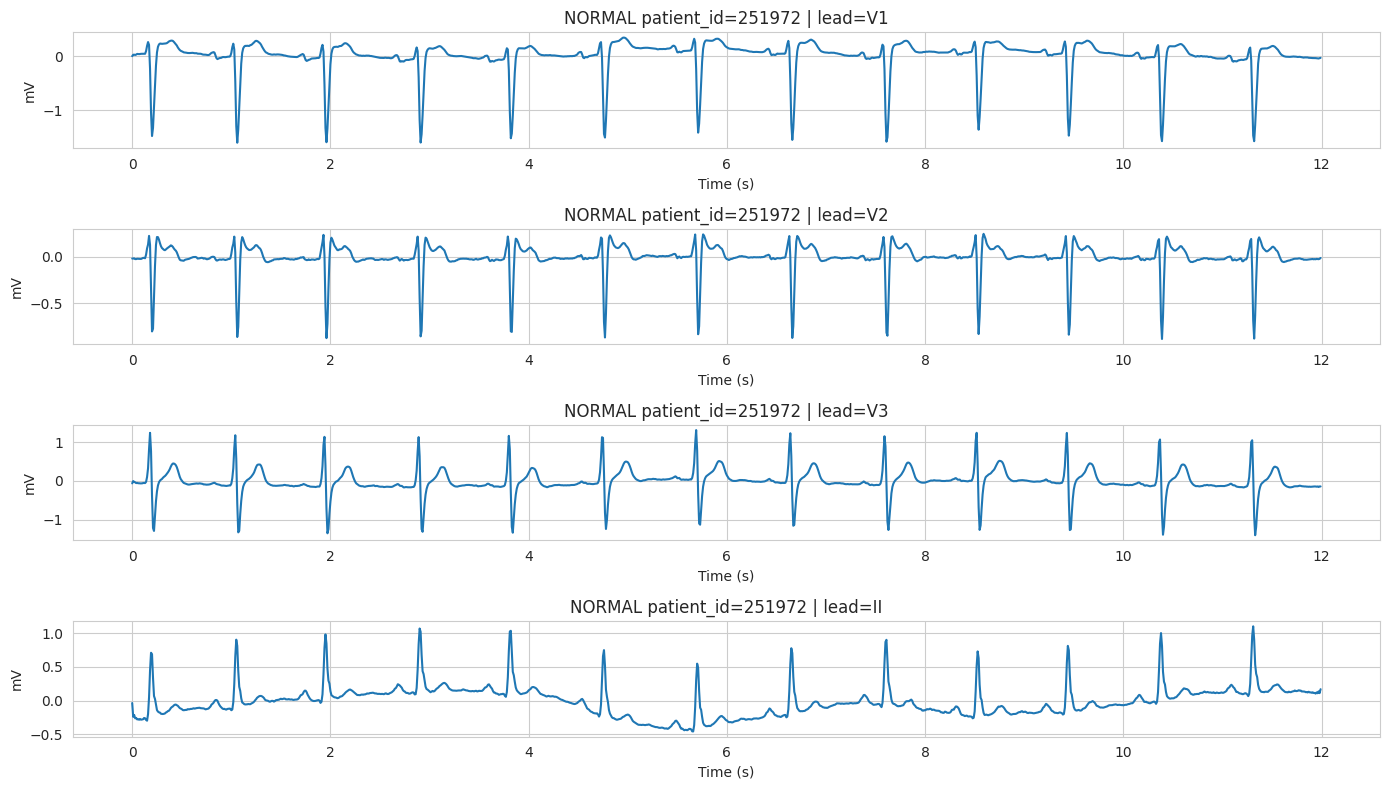

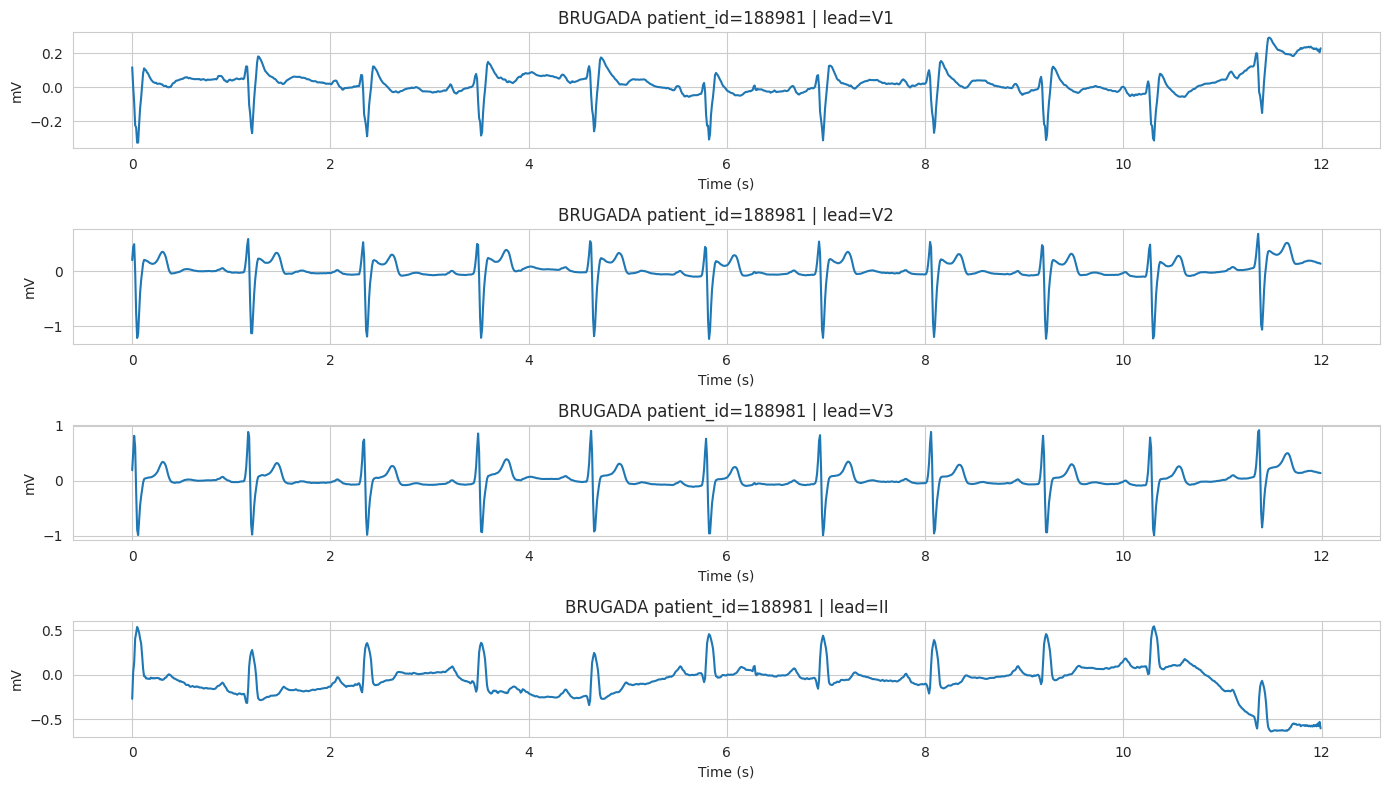

In [7]:
normal_id = metadata.loc[metadata["brugada"] == 0, "patient_id"].iloc[0]
brugada_id = metadata.loc[metadata["brugada"] == 1, "patient_id"].iloc[0]

def plot_selected_leads(patient_id, leads_to_plot=("V1", "V2", "V3", "II"), title_prefix=""):
    X, leads, fs = load_ecg_record(patient_id)
    t = np.arange(len(X)) / fs
    
    plt.figure(figsize=(14, 8))
    for i, ld in enumerate(leads_to_plot, 1):
        idx = leads.index(ld)
        plt.subplot(len(leads_to_plot), 1, i)
        plt.plot(t, X[:, idx])
        plt.title(f"{title_prefix} patient_id={patient_id} | lead={ld}")
        plt.xlabel("Time (s)")
        plt.ylabel("mV")
    plt.tight_layout()
    plt.show()

plot_selected_leads(normal_id, title_prefix="NORMAL")
plot_selected_leads(brugada_id, title_prefix="BRUGADA")

# 3. Preprocessing & beat extraction

Karena release dataset tidak memberi preprocessing tambahan, kita akan:
1. bandpass filter 0.5–40 Hz
2. robust normalization per lead
3. deteksi R-peak
4. ekstraksi median beat

Tujuannya supaya model lebih fokus ke morfologi yang relevan.

In [8]:
def bandpass_filter(x, fs, low=0.5, high=40.0, order=3):
    nyq = 0.5 * fs
    low = max(low / nyq, 1e-4)
    high = min(high / nyq, 0.99)
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, x, axis=0)

def robust_scale(x):
    med = np.median(x, axis=0, keepdims=True)
    mad = np.median(np.abs(x - med), axis=0, keepdims=True)
    mad = np.where(mad < 1e-6, 1.0, mad)
    return (x - med) / (1.4826 * mad)

def detect_r_peaks(signal_1d, fs):
    x = signal_1d.copy()
    if len(x) >= 11:
        x = savgol_filter(x, 11, 3)
    x = x - np.median(x)

    prominence = max(0.15, np.std(x) * 0.5)
    distance = int(0.45 * fs)

    peaks, _ = find_peaks(x, distance=distance, prominence=prominence)

    if len(peaks) == 0:
        peaks, _ = find_peaks(np.abs(x), distance=distance, prominence=np.std(np.abs(x)) * 0.3)
    return peaks

def extract_median_beat(X, leads, fs):
    lead_priority = ["II", "V2", "V1", "V3", "I"]
    pre = int(0.25 * fs)
    post = int(0.45 * fs)

    peaks = np.array([])
    for ref_lead in lead_priority:
        if ref_lead in leads:
            ref_idx = leads.index(ref_lead)
            peaks = detect_r_peaks(X[:, ref_idx], fs)
            peaks = peaks[(peaks > pre) & (peaks < len(X) - post)]
            if len(peaks) >= 2:
                break

    beats = []
    for p in peaks:
        beat = X[p-pre:p+post, :]
        if beat.shape[0] == pre + post:
            beats.append(beat)

    if len(beats) == 0:
        center = len(X) // 2
        beat = X[max(0, center-pre):min(len(X), center+post), :]
        pad = np.zeros((pre + post, X.shape[1]), dtype=np.float32)
        pad[:beat.shape[0], :] = beat
        return pad, pre

    median_beat = np.median(np.stack(beats, axis=0), axis=0)
    return median_beat, pre

In [9]:
def zero_crossings(x):
    return np.sum(np.diff(np.signbit(x)).astype(int))

def safe_slope(y):
    if len(y) < 2:
        return 0.0
    xs = np.arange(len(y))
    return float(np.polyfit(xs, y, 1)[0])

def extract_strip_features(x, prefix):
    feats = {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_min": float(np.min(x)),
        f"{prefix}_max": float(np.max(x)),
        f"{prefix}_ptp": float(np.ptp(x)),
        f"{prefix}_median": float(np.median(x)),
        f"{prefix}_q05": float(np.quantile(x, 0.05)),
        f"{prefix}_q25": float(np.quantile(x, 0.25)),
        f"{prefix}_q75": float(np.quantile(x, 0.75)),
        f"{prefix}_q95": float(np.quantile(x, 0.95)),
        f"{prefix}_rms": float(np.sqrt(np.mean(x**2))),
        f"{prefix}_abs_area": float(np.sum(np.abs(x))),
        f"{prefix}_energy": float(np.sum(x**2)),
        f"{prefix}_skew": float(skew(x)),
        f"{prefix}_kurtosis": float(kurtosis(x)),
        f"{prefix}_zero_cross": float(zero_crossings(x)),
    }
    return feats

def extract_beat_features(beat_1d, r_idx, fs, prefix):
    # windows around R peak
    q_win = beat_1d[max(0, r_idx-8):r_idx]
    s_win = beat_1d[r_idx:min(len(beat_1d), r_idx+12)]
    st_win = beat_1d[min(len(beat_1d), r_idx+6):min(len(beat_1d), r_idx+16)]
    t_win = beat_1d[min(len(beat_1d), r_idx+18):min(len(beat_1d), r_idx+35)]
    pre_win = beat_1d[max(0, r_idx-10):max(1, r_idx-2)]

    feats = {
        f"{prefix}_beat_r_amp": float(beat_1d[r_idx]),
        f"{prefix}_beat_q_min": float(np.min(q_win)) if len(q_win) else 0.0,
        f"{prefix}_beat_s_min": float(np.min(s_win)) if len(s_win) else 0.0,
        f"{prefix}_beat_qrs_range": float(np.ptp(beat_1d[max(0, r_idx-6):min(len(beat_1d), r_idx+10)])),
        f"{prefix}_beat_st_mean": float(np.mean(st_win)) if len(st_win) else 0.0,
        f"{prefix}_beat_st_max": float(np.max(st_win)) if len(st_win) else 0.0,
        f"{prefix}_beat_st_slope": float(safe_slope(st_win)) if len(st_win) else 0.0,
        f"{prefix}_beat_t_max": float(np.max(t_win)) if len(t_win) else 0.0,
        f"{prefix}_beat_t_mean": float(np.mean(t_win)) if len(t_win) else 0.0,
        f"{prefix}_beat_pre_mean": float(np.mean(pre_win)) if len(pre_win) else 0.0,
        f"{prefix}_beat_area": float(np.trapz(np.abs(beat_1d))),
        f"{prefix}_beat_energy": float(np.sum(beat_1d**2)),
    }
    return feats

def build_feature_row(patient_id):
    X, leads, fs = load_ecg_record(patient_id)

    # preprocessing
    Xf = bandpass_filter(X, fs=fs, low=0.5, high=40.0, order=3)
    Xn = robust_scale(Xf)

    median_beat, r_idx = extract_median_beat(Xn, leads, fs)

    feats = {}
    feats["patient_id"] = int(patient_id)
    feats["fs"] = fs
    feats["n_samples"] = Xn.shape[0]

    # full-strip features
    for i, ld in enumerate(leads):
        feats.update(extract_strip_features(Xn[:, i], prefix=f"{ld}_strip"))

    # median-beat morphology
    for i, ld in enumerate(leads):
        feats.update(extract_beat_features(median_beat[:, i], r_idx=r_idx, fs=fs, prefix=f"{ld}"))

    # clinically focused combined features (V1-V3)
    for ld in ["V1", "V2", "V3"]:
        i = leads.index(ld)
        seg = median_beat[:, i]
        feats[f"{ld}_post_r_100ms_mean"] = float(np.mean(seg[r_idx+5:r_idx+15]))
        feats[f"{ld}_post_r_150ms_mean"] = float(np.mean(seg[r_idx+10:r_idx+20]))
        feats[f"{ld}_post_r_200ms_mean"] = float(np.mean(seg[r_idx+15:r_idx+25]))

    feats["V1_V2_st_mean_avg"] = np.mean([feats["V1_beat_st_mean"], feats["V2_beat_st_mean"]])
    feats["V1_V3_st_mean_avg"] = np.mean([feats["V1_beat_st_mean"], feats["V3_beat_st_mean"]])
    feats["V1_V2_qrs_avg"] = np.mean([feats["V1_beat_qrs_range"], feats["V2_beat_qrs_range"]])
    feats["V1_V2_strip_energy_avg"] = np.mean([feats["V1_strip_energy"], feats["V2_strip_energy"]])
    feats["V1_minus_V2_st_mean"] = feats["V1_beat_st_mean"] - feats["V2_beat_st_mean"]
    feats["V2_minus_V3_st_mean"] = feats["V2_beat_st_mean"] - feats["V3_beat_st_mean"]

    # cross-lead correlations (important for multilead ECG consistency)
    for a, b in [("V1", "V2"), ("V2", "V3"), ("I", "II"), ("II", "V1")]:
        ia, ib = leads.index(a), leads.index(b)
        corr = np.corrcoef(Xn[:, ia], Xn[:, ib])[0, 1]
        feats[f"corr_{a}_{b}"] = float(np.nan_to_num(corr))

    return feats

In [10]:
def zero_crossings(x):
    return np.sum(np.diff(np.signbit(x)).astype(int))

def safe_slope(y):
    if len(y) < 2:
        return 0.0
    xs = np.arange(len(y))
    return float(np.polyfit(xs, y, 1)[0])

def extract_strip_features(x, prefix):
    feats = {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_min": float(np.min(x)),
        f"{prefix}_max": float(np.max(x)),
        f"{prefix}_ptp": float(np.ptp(x)),
        f"{prefix}_median": float(np.median(x)),
        f"{prefix}_q05": float(np.quantile(x, 0.05)),
        f"{prefix}_q25": float(np.quantile(x, 0.25)),
        f"{prefix}_q75": float(np.quantile(x, 0.75)),
        f"{prefix}_q95": float(np.quantile(x, 0.95)),
        f"{prefix}_rms": float(np.sqrt(np.mean(x**2))),
        f"{prefix}_abs_area": float(np.sum(np.abs(x))),
        f"{prefix}_energy": float(np.sum(x**2)),
        f"{prefix}_skew": float(skew(x)),
        f"{prefix}_kurtosis": float(kurtosis(x)),
        f"{prefix}_zero_cross": float(zero_crossings(x)),
    }
    return feats

def extract_beat_features(beat_1d, r_idx, fs, prefix):
    # windows around R peak
    q_win = beat_1d[max(0, r_idx-8):r_idx]
    s_win = beat_1d[r_idx:min(len(beat_1d), r_idx+12)]
    st_win = beat_1d[min(len(beat_1d), r_idx+6):min(len(beat_1d), r_idx+16)]
    t_win = beat_1d[min(len(beat_1d), r_idx+18):min(len(beat_1d), r_idx+35)]
    pre_win = beat_1d[max(0, r_idx-10):max(1, r_idx-2)]

    feats = {
        f"{prefix}_beat_r_amp": float(beat_1d[r_idx]),
        f"{prefix}_beat_q_min": float(np.min(q_win)) if len(q_win) else 0.0,
        f"{prefix}_beat_s_min": float(np.min(s_win)) if len(s_win) else 0.0,
        f"{prefix}_beat_qrs_range": float(np.ptp(beat_1d[max(0, r_idx-6):min(len(beat_1d), r_idx+10)])),
        f"{prefix}_beat_st_mean": float(np.mean(st_win)) if len(st_win) else 0.0,
        f"{prefix}_beat_st_max": float(np.max(st_win)) if len(st_win) else 0.0,
        f"{prefix}_beat_st_slope": float(safe_slope(st_win)) if len(st_win) else 0.0,
        f"{prefix}_beat_t_max": float(np.max(t_win)) if len(t_win) else 0.0,
        f"{prefix}_beat_t_mean": float(np.mean(t_win)) if len(t_win) else 0.0,
        f"{prefix}_beat_pre_mean": float(np.mean(pre_win)) if len(pre_win) else 0.0,
        f"{prefix}_beat_area": float(np.trapz(np.abs(beat_1d))),
        f"{prefix}_beat_energy": float(np.sum(beat_1d**2)),
    }
    return feats

def build_feature_row(patient_id):
    X, leads, fs = load_ecg_record(patient_id)

    # preprocessing
    Xf = bandpass_filter(X, fs=fs, low=0.5, high=40.0, order=3)
    Xn = robust_scale(Xf)

    median_beat, r_idx = extract_median_beat(Xn, leads, fs)

    feats = {}
    feats["patient_id"] = int(patient_id)
    feats["fs"] = fs
    feats["n_samples"] = Xn.shape[0]

    # full-strip features
    for i, ld in enumerate(leads):
        feats.update(extract_strip_features(Xn[:, i], prefix=f"{ld}_strip"))

    # median-beat morphology
    for i, ld in enumerate(leads):
        feats.update(extract_beat_features(median_beat[:, i], r_idx=r_idx, fs=fs, prefix=f"{ld}"))

    # clinically focused combined features (V1-V3)
    for ld in ["V1", "V2", "V3"]:
        i = leads.index(ld)
        seg = median_beat[:, i]
        feats[f"{ld}_post_r_100ms_mean"] = float(np.mean(seg[r_idx+5:r_idx+15]))
        feats[f"{ld}_post_r_150ms_mean"] = float(np.mean(seg[r_idx+10:r_idx+20]))
        feats[f"{ld}_post_r_200ms_mean"] = float(np.mean(seg[r_idx+15:r_idx+25]))

    feats["V1_V2_st_mean_avg"] = np.mean([feats["V1_beat_st_mean"], feats["V2_beat_st_mean"]])
    feats["V1_V3_st_mean_avg"] = np.mean([feats["V1_beat_st_mean"], feats["V3_beat_st_mean"]])
    feats["V1_V2_qrs_avg"] = np.mean([feats["V1_beat_qrs_range"], feats["V2_beat_qrs_range"]])
    feats["V1_V2_strip_energy_avg"] = np.mean([feats["V1_strip_energy"], feats["V2_strip_energy"]])
    feats["V1_minus_V2_st_mean"] = feats["V1_beat_st_mean"] - feats["V2_beat_st_mean"]
    feats["V2_minus_V3_st_mean"] = feats["V2_beat_st_mean"] - feats["V3_beat_st_mean"]

    # cross-lead correlations (important for multilead ECG consistency)
    for a, b in [("V1", "V2"), ("V2", "V3"), ("I", "II"), ("II", "V1")]:
        ia, ib = leads.index(a), leads.index(b)
        corr = np.corrcoef(Xn[:, ia], Xn[:, ib])[0, 1]
        feats[f"corr_{a}_{b}"] = float(np.nan_to_num(corr))

    return feats

In [11]:
rows = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata)):
    patient_id = row["patient_id"]
    try:
        feats = build_feature_row(patient_id)
        feats["target"] = int(row["brugada"])
        if "basal_pattern" in row:
            feats["basal_pattern_meta"] = row["basal_pattern"]
        if "sudden_death" in row:
            feats["sudden_death_meta"] = row["sudden_death"]
        rows.append(feats)
    except Exception as e:
        print(f"Error on patient_id={patient_id}: {e}")

features_df = pd.DataFrame(rows)
print(features_df.shape)
display(features_df.head())

  0%|          | 0/363 [00:00<?, ?it/s]

(363, 361)


,patient_id,fs,n_samples,I_strip_mean,I_strip_std,I_strip_min,I_strip_max,I_strip_ptp,I_strip_median,I_strip_q05,...,V1_V2_strip_energy_avg,V1_minus_V2_st_mean,V2_minus_V3_st_mean,corr_V1_V2,corr_V2_V3,corr_I_II,corr_II_V1,target,basal_pattern_meta,sudden_death_meta
0,188981,100,1200,0.922231,4.182405,-12.646047,24.202060,36.848107,0.000000e+00,-3.892976,...,19957.574082,-0.488959,1.664284,0.753963,0.902374,-0.174618,-0.852009,1,1,0
1,251972,100,1200,1.277890,4.183901,-2.111954,26.794834,28.906789,0.000000e+00,-1.130447,...,28366.185630,-2.310849,2.511937,0.913602,0.510476,0.970997,-0.797199,0,0,0
2,265715,100,1200,0.502277,2.299660,-4.959201,13.965964,18.925165,-3.133344e-17,-1.298631,...,7613.994524,1.800435,1.577656,0.207699,0.777851,0.971860,-0.261951,0,0,0
3,267628,100,1200,1.423858,4.425628,-3.004401,29.136914,32.141315,0.000000e+00,-1.253809,...,55152.572945,0.365918,3.253652,0.704110,-0.342152,0.977791,-0.940299,0,0,0
4,267630,100,1200,-0.144309,32.720990,-112.801398,264.618021,377.419419,0.000000e+00,-38.640424,...,198318.945815,4.609158,-1.454587,0.681842,0.309146,0.747640,-0.708924,1,0,0


sudden_death_meta    0.0
patient_id           0.0
fs                   0.0
n_samples            0.0
I_strip_mean         0.0
I_strip_std          0.0
I_strip_min          0.0
I_strip_max          0.0
I_strip_ptp          0.0
V5_beat_st_slope     0.0
V5_beat_t_max        0.0
V5_beat_t_mean       0.0
V5_beat_pre_mean     0.0
V5_beat_area         0.0
V5_beat_energy       0.0
V6_beat_r_amp        0.0
V6_beat_q_min        0.0
V4_beat_area         0.0
V4_beat_energy       0.0
V5_beat_r_amp        0.0
dtype: float64

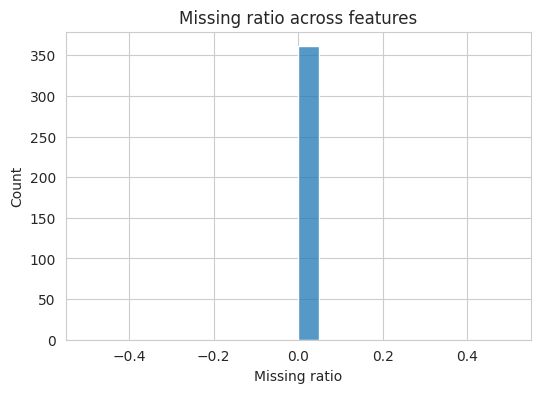

In [12]:
missing_summary = features_df.isna().mean().sort_values(ascending=False)
display(missing_summary.head(20))

plt.figure(figsize=(6,4))
sns.histplot(missing_summary.values, bins=20)
plt.title("Missing ratio across features")
plt.xlabel("Missing ratio")
plt.show()

# 4. Train / validation / test split

Karena data kecil, kita gunakan:
- hold-out test set 20%
- 5-fold CV di data train
- threshold tuning berbasis OOF prediction

In [13]:
print("Unique target sebelum cleaning:")
print(features_df["target"].value_counts(dropna=False))
print("dtype:", features_df["target"].dtype)

Unique target sebelum cleaning:
target
0    287
1     69
2      7
Name: count, dtype: int64
dtype: int64


In [14]:
target_col = "target"
drop_cols = ["patient_id", "target"]

# Paksa target jadi numeric
features_df[target_col] = pd.to_numeric(features_df[target_col], errors="coerce")

# Simpan hanya label biner 0/1
features_df = features_df[features_df[target_col].isin([0, 1])].copy()
features_df[target_col] = features_df[target_col].astype(int)

print("Unique target setelah cleaning:")
print(features_df[target_col].value_counts(dropna=False))

X = features_df.drop(columns=drop_cols)
y = features_df[target_col].astype(int).values

assert set(np.unique(y)).issubset({0, 1}), f"Target masih bukan biner: {np.unique(y)}"

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train_df.shape)
print("Test shape :", X_test_df.shape)
print("Train label dist:", np.unique(y_train, return_counts=True))
print("Test label dist :", np.unique(y_test, return_counts=True))

Unique target setelah cleaning:
target
0    287
1     69
Name: count, dtype: int64
Train shape: (284, 359)
Test shape : (72, 359)
Train label dist: (array([0, 1]), array([229,  55]))
Test label dist : (array([0, 1]), array([58, 14]))


In [15]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train_df)
X_test = imputer.transform(X_test_df)

feature_names = X_train_df.columns.tolist()

scale_pos_weight = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
print("scale_pos_weight:", scale_pos_weight)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_pred = np.zeros(len(y_train), dtype=float)

models = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr = y_train[tr_idx].astype(int)
    y_va = y_train[va_idx].astype(int)

    print(f"\nFold {fold}")
    print("y_tr dist:", np.unique(y_tr, return_counts=True))
    print("y_va dist:", np.unique(y_va, return_counts=True))

    model = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.3,
        reg_lambda=1.5,
        min_child_weight=2,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE + fold,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist"
    )

    model.fit(X_tr, y_tr)

    va_pred = model.predict_proba(X_va)[:, 1].astype(float)
    oof_pred[va_idx] = va_pred
    models.append(model)

    fold_auc = roc_auc_score(y_va, va_pred)
    print(f"Fold {fold} AUC: {fold_auc:.4f}")

print("\nOOF AUC:", roc_auc_score(y_train.astype(int), oof_pred))

scale_pos_weight: 4.163636363636364

Fold 1
y_tr dist: (array([0, 1]), array([183,  44]))
y_va dist: (array([0, 1]), array([46, 11]))
Fold 1 AUC: 0.7945

Fold 2
y_tr dist: (array([0, 1]), array([183,  44]))
y_va dist: (array([0, 1]), array([46, 11]))
Fold 2 AUC: 0.7628

Fold 3
y_tr dist: (array([0, 1]), array([183,  44]))
y_va dist: (array([0, 1]), array([46, 11]))
Fold 3 AUC: 0.8202

Fold 4
y_tr dist: (array([0, 1]), array([183,  44]))
y_va dist: (array([0, 1]), array([46, 11]))
Fold 4 AUC: 0.8123

Fold 5
y_tr dist: (array([0, 1]), array([184,  44]))
y_va dist: (array([0, 1]), array([45, 11]))
Fold 5 AUC: 0.8182

OOF AUC: 0.7987296546248511


Best threshold: 0.27
Best OOF F1   : 0.5254237288135594


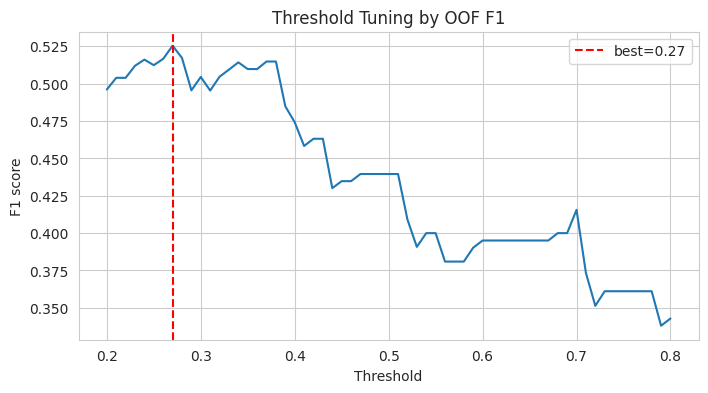

In [16]:
thresholds = np.linspace(0.20, 0.80, 61)
f1_scores = [f1_score(y_train, (oof_pred >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold:", best_threshold)
print("Best OOF F1   :", max(f1_scores))

plt.figure(figsize=(8,4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"best={best_threshold:.2f}")
plt.title("Threshold Tuning by OOF F1")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.legend()
plt.show()

In [17]:
final_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.3,
    reg_lambda=1.5,
    min_child_weight=2,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist"
)

final_model.fit(X_train, y_train)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

In [18]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def sensitivity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

test_auc = roc_auc_score(y_test, test_proba)
test_f1 = f1_score(y_test, test_pred)
test_acc = accuracy_score(y_test, test_pred)
test_sens = sensitivity_score(y_test, test_pred)
test_spec = specificity_score(y_test, test_pred)

print(f"Test AUC         : {test_auc:.4f}")
print(f"Test F1          : {test_f1:.4f}")
print(f"Test Accuracy    : {test_acc:.4f}")
print(f"Test Sensitivity : {test_sens:.4f}")
print(f"Test Specificity : {test_spec:.4f}")

print("\nClassification Report")
print(classification_report(y_test, test_pred, digits=4))

Test AUC         : 0.8350
Test F1          : 0.4800
Test Accuracy    : 0.8194
Test Sensitivity : 0.4286
Test Specificity : 0.9138

Classification Report
              precision    recall  f1-score   support

           0     0.8689    0.9138    0.8908        58
           1     0.5455    0.4286    0.4800        14

    accuracy                         0.8194        72
   macro avg     0.7072    0.6712    0.6854        72
weighted avg     0.8060    0.8194    0.8109        72



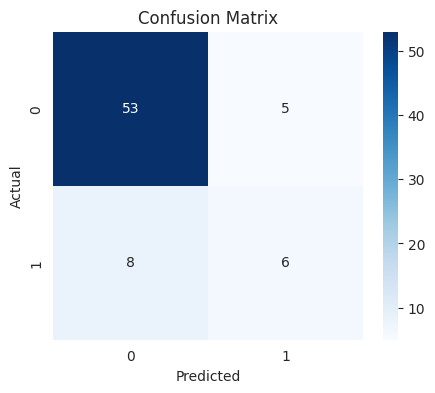

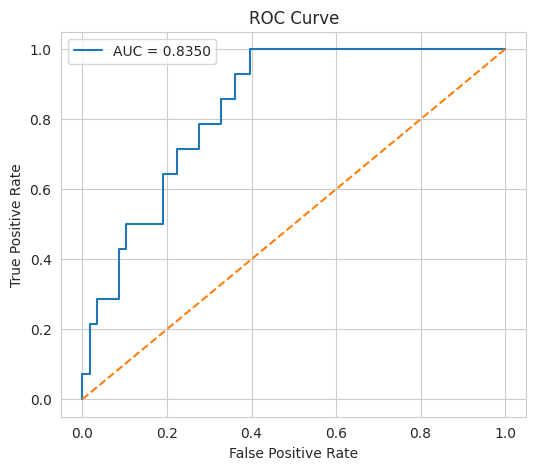

In [19]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

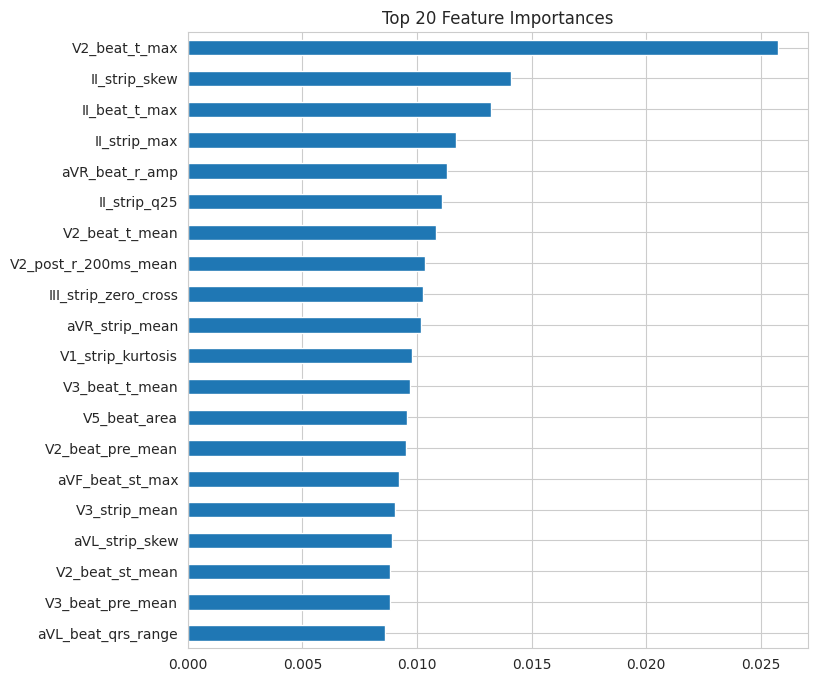

V2_beat_t_max           0.025781
II_strip_skew           0.014088
II_beat_t_max           0.013235
II_strip_max            0.011715
aVR_beat_r_amp          0.011291
II_strip_q25            0.011107
V2_beat_t_mean          0.010847
V2_post_r_200ms_mean    0.010340
III_strip_zero_cross    0.010266
aVR_strip_mean          0.010177
V1_strip_kurtosis       0.009772
V3_beat_t_mean          0.009705
V5_beat_area            0.009567
V2_beat_pre_mean        0.009532
aVF_beat_st_max         0.009210
V3_strip_mean           0.009047
aVL_strip_skew          0.008916
V2_beat_st_mean         0.008810
V3_beat_pre_mean        0.008802
aVL_beat_qrs_range      0.008618
dtype: float32

In [20]:
importance = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)

top20 = importance.head(20).sort_values()
plt.figure(figsize=(8,8))
top20.plot(kind="barh")
plt.title("Top 20 Feature Importances")
plt.show()

display(importance.head(20))

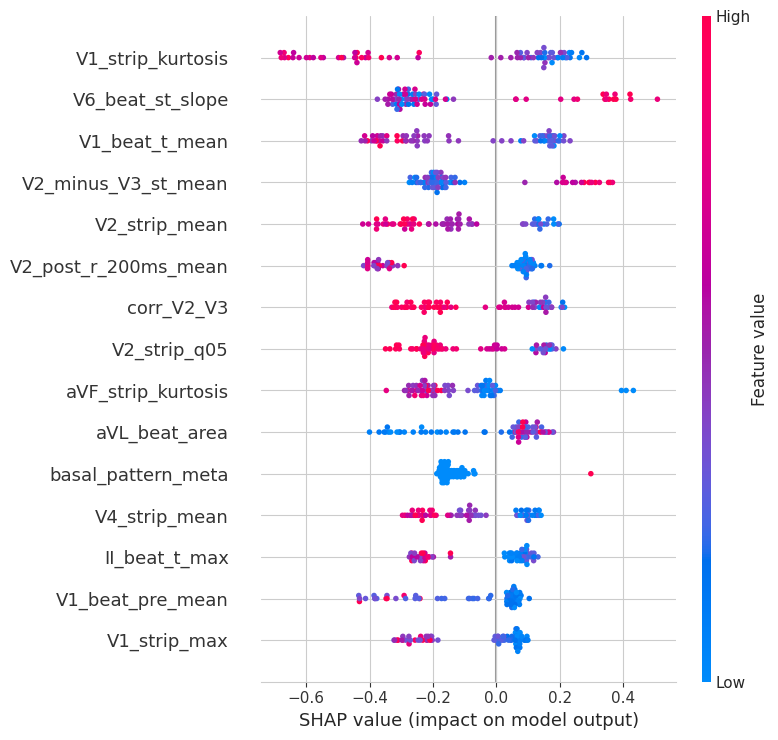

In [21]:
X_test_df_imputed = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_df_imputed)

shap.summary_plot(shap_values, X_test_df_imputed, max_display=15)

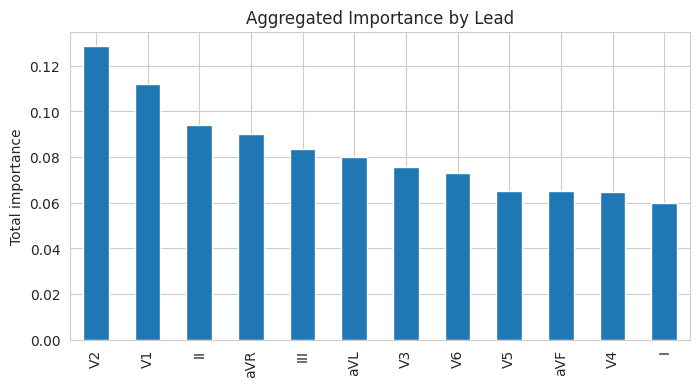

V2     0.128635
V1     0.112032
II     0.094114
aVR    0.090028
III    0.083608
aVL    0.079938
V3     0.075733
V6     0.072830
V5     0.065332
aVF    0.065010
V4     0.064712
I      0.060080
dtype: float32

In [22]:
lead_scores = {}

for lead in STANDARD_LEADS:
    lead_scores[lead] = importance[importance.index.str.startswith(f"{lead}_")].sum()

lead_scores = pd.Series(lead_scores).sort_values(ascending=False)

plt.figure(figsize=(8,4))
lead_scores.plot(kind="bar")
plt.title("Aggregated Importance by Lead")
plt.ylabel("Total importance")
plt.show()

display(lead_scores)

In [23]:
test_results = X_test_df.copy().reset_index(drop=True)
test_results["target"] = y_test
test_results["pred_proba"] = test_proba
test_results["pred_label"] = test_pred

test_results.to_csv("brugada_test_predictions.csv", index=False)
print("Saved: brugada_test_predictions.csv")

Saved: brugada_test_predictions.csv


# Conclusion

Pipeline ini berhasil:
- membaca data ECG WFDB secara otomatis dari Kaggle input
- melakukan preprocessing dan ekstraksi median beat
- membuat fitur morfologi ECG yang explainable
- melatih model XGBoost untuk klasifikasi Brugada vs Normal
- mengevaluasi model dengan AUC, F1, sensitivity, specificity
- memberikan interpretasi melalui feature importance dan SHAP

Next improvement:
1. menambah nested CV
2. tuning hyperparameter lebih agresif
3. membandingkan feature-based model vs 1D CNN
4. membuat lead-focused augmentation khusus V1–V3